🚀 Starting Real-Data Verification for lcmv_stats...

1️⃣ Testing Atlas & Utils...
   ✅ Loaded 448 CIMT ROIs
   ✅ Motor Network has 80 ROIs
   ✅ Mapping 'Sbj001' -> 'sub-001'

2️⃣ Testing Event-Locked Epoching...
   ✅ sub-001: 16 in-phase epochs extracted

3️⃣ Testing WPLI Connectivity...
   ✅ WPLI Matrix shape: (80, 80)


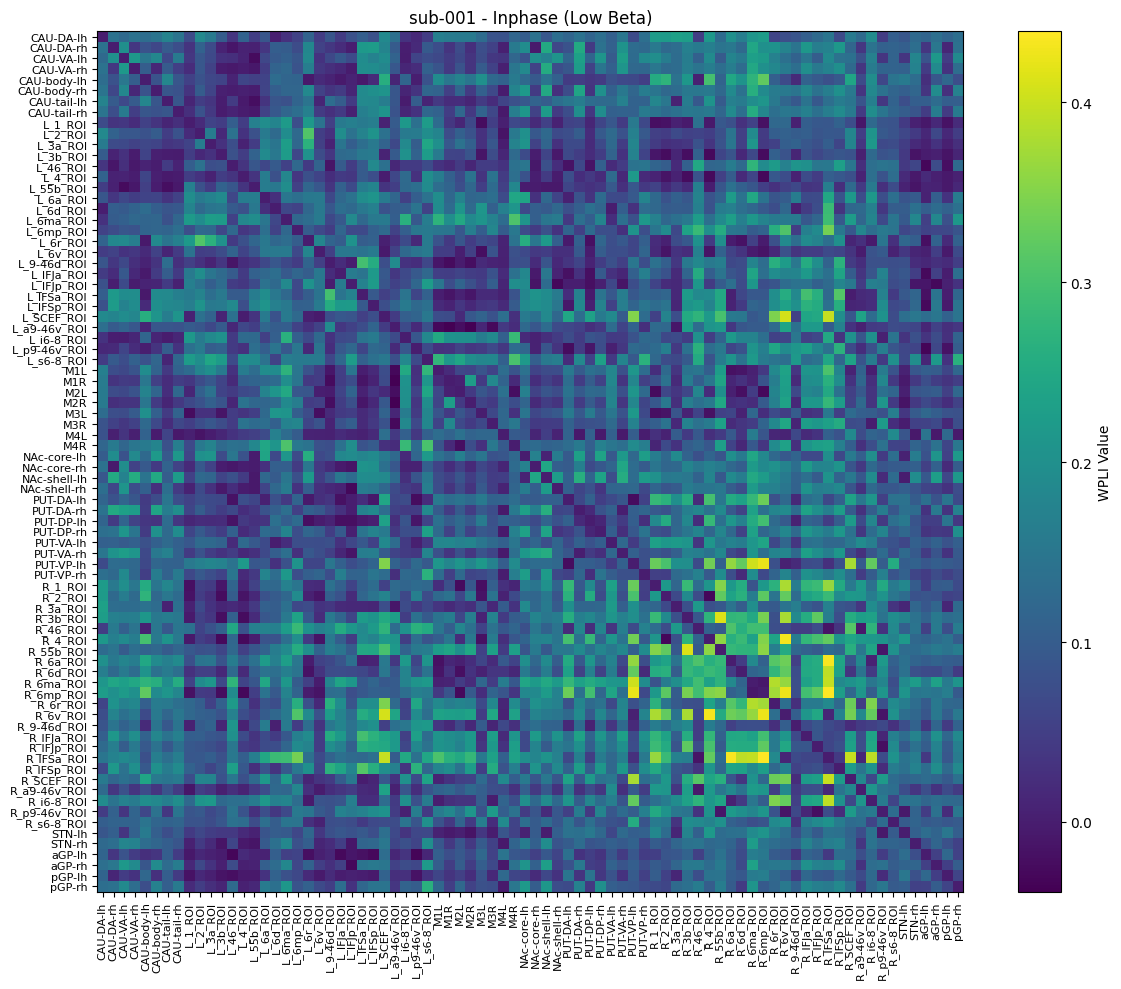

   ✅ Connectivity Matrix Plotted

4️⃣ Testing Edge-Wise Statistics...
   Processing 12 subjects for statistics...
   ✅ Found 3160 significant edges (p<0.05)


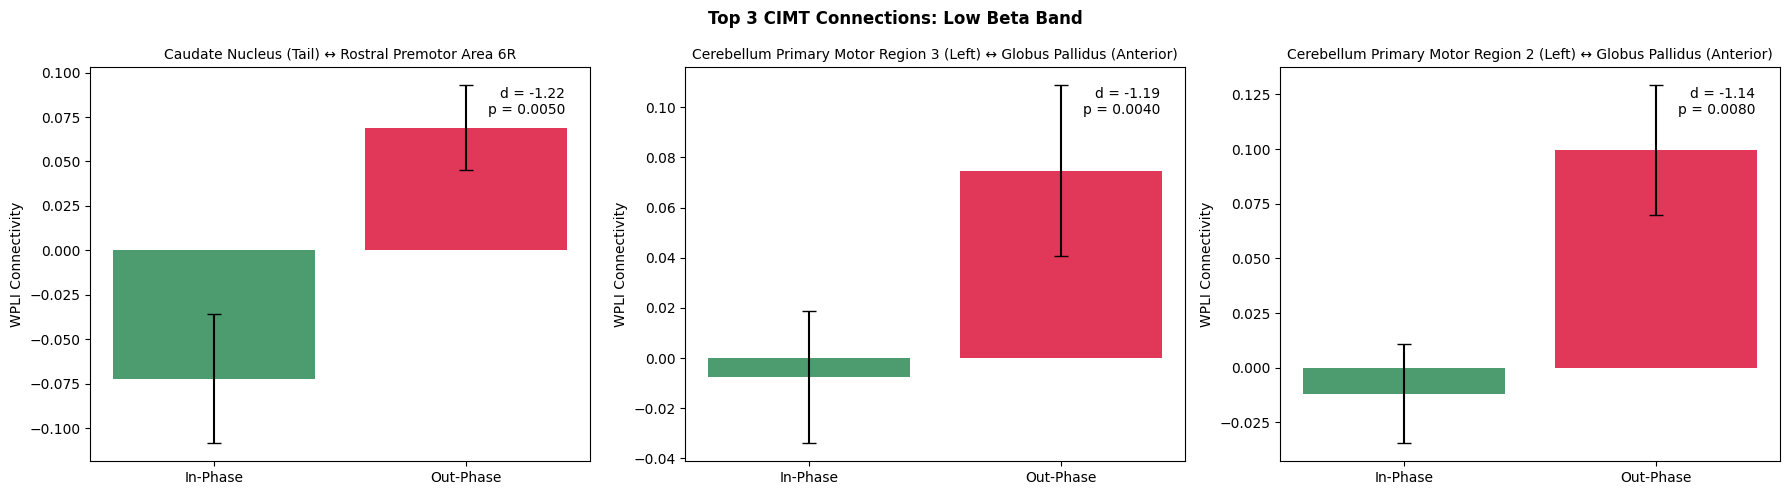

   ✅ Top-Edges Plot Saved
   ✅ Markdown Report Generated

5️⃣ Testing Targeted GPDC Extraction...


Maximum iterations reached. 0 of 1 converged
Maximum iterations reached. 0 of 1 converged
Maximum iterations reached. 0 of 1 converged
Maximum iterations reached. 0 of 1 converged
Maximum iterations reached. 0 of 1 converged
Maximum iterations reached. 0 of 1 converged


   ✅ Targeted GPDC shape: (9, 9) for 9 ROIs
   ✅ ROIs involved: CAU-tail-lh, CAU-tail-rh, L_2_ROI...

6️⃣ Testing Spectrogram Clustering...
   ✅ Cluster test complete. Found 0 significant clusters.
   ✅ Spectral Results Saved

🏁 Real-Data Verification Complete! Check the 'results/real_data_test' folder.


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import lcmv_stats as ls
import matplotlib.pyplot as plt

# ───────────── CONFIGURATION ─────────────
PROJECT_BASE = Path("/")
LCMV_ROOT = PROJECT_BASE / "derivatives/lcmv"
EVENTS_CSV = PROJECT_BASE / "data/csv/bima_events.csv"
OUTPUT_DIR = Path("/data_test")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data Verification for lcmv_stats...")

# ───────────── 1. ATLAS & UTILS CHECK ─────────────
print("\n1️⃣ Testing Atlas & Utils...")
labels = ls.get_cimt_labels()
print(f"   ✅ Loaded {len(labels)} CIMT ROIs")

motor_indices = ls.get_motor_network_indices()
print(f"   ✅ Motor Network has {len(motor_indices)} ROIs")

test_id = ls.utils.map_subject_to_subj("Sbj001")
print(f"   ✅ Mapping 'Sbj001' -> '{test_id}'")

# ───────────── 2. EPOCHING (Event-Locked) ─────────────
print("\n2️⃣ Testing Event-Locked Epoching...")
events_df = pd.read_csv(EVENTS_CSV)
events_df = events_df[events_df['notes'] == 'good']
subject_ids = [ls.utils.map_subject_to_subj(name) for name in events_df['subject'].unique()]

if not subject_ids:
    raise ValueError("No subjects found in events CSV.")

test_subj = subject_ids[0]
subj_events = events_df[events_df['subject'].apply(lambda x: ls.utils.map_subject_to_subj(x) == test_subj)]

in_ep, out_ep = ls.epoching.extract_event_epochs(
    subject_id=test_subj,
    lcmv_root=LCMV_ROOT,
    events_df=subj_events,
    pre_sec=5.0, post_sec=5.0,
    epoch_duration=2.0, overlap=0.8
)
print(f"   ✅ {test_subj}: {in_ep.shape[0]} in-phase epochs extracted")

# ───────────── 3. CONNECTIVITY (WPLI) ─────────────
print("\n3️⃣ Testing WPLI Connectivity...")
sfreq = ls.utils.get_subject_sfreq(test_subj, LCMV_ROOT)
in_conn, out_conn = ls.connectivity.extract_wpli_features(
    epochs_in=in_ep, epochs_out=out_ep, band="low_beta", sfreq=sfreq
)

print(f"   ✅ WPLI Matrix shape: {in_conn.shape}")
ls.visualization.plot_connectivity_matrix(in_conn, band="low_beta", condition="inphase", title=test_subj)
print("   ✅ Connectivity Matrix Plotted")

# ───────────── 4. STATISTICS (Permutation) ─────────────
print("\n4️⃣ Testing Edge-Wise Statistics...")
all_in_mats = []
all_out_mats = []
valid_subs = []

print(f"   Processing {len(subject_ids)} subjects for statistics...")
for sid in subject_ids: 
    s_events = events_df[events_df['subject'].apply(lambda x: ls.utils.map_subject_to_subj(x) == sid)]
    i_ep, o_ep = ls.epoching.extract_event_epochs(sid, LCMV_ROOT, s_events)
    
    if i_ep.size > 0:
        sf = ls.utils.get_subject_sfreq(sid, LCMV_ROOT)
        ic, oc = ls.connectivity.extract_wpli_features(i_ep, o_ep, "low_beta", sf)
        if ic is not None:
            triu_ix = np.triu_indices(ic.shape[0], k=1)
            all_in_mats.append(ic[triu_ix])
            all_out_mats.append(oc[triu_ix])
            valid_subs.append(sid)

if len(valid_subs) < 3:
    raise ValueError(f"Need at least 3 subjects for stats, found {len(valid_subs)}")

in_data = np.stack(all_in_mats)
out_data = np.stack(all_out_mats)

df_sig = ls.statistics.run_edgewise_permutation(
    in_data=in_data, out_data=out_data, n_permutations=1000
)
print(f"   ✅ Found {len(df_sig)} significant edges (p<0.05)")

ls.reporting.plot_top_edges(df_sig, band="low_beta", n_top=3, save_path=OUTPUT_DIR / "test_top_edges.png")
print("   ✅ Top-Edges Plot Saved")

ls.reporting.generate_markdown_report(df_sig.assign(band="low_beta"), OUTPUT_DIR / "test_report.md")
print("   ✅ Markdown Report Generated")

# ───────────── 5. TARGETED GPDC (Using Significant Edges) ─────────────
print("\n5️⃣ Testing Targeted GPDC Extraction...")
top_sig_edges = df_sig.nlargest(5, 'abs_d')

s_events = events_df[events_df['subject'].apply(lambda x: ls.utils.map_subject_to_subj(x) == test_subj)]
in_ep_test, out_ep_test = ls.epoching.extract_event_epochs(test_subj, LCMV_ROOT, s_events)

sfreq = ls.utils.get_subject_sfreq(test_subj, LCMV_ROOT)

in_gpdc, out_gpdc, roi_names = ls.connectivity.extract_gpdc_features(
    epochs_in=in_ep_test,
    epochs_out=out_ep_test,
    sig_df=top_sig_edges,
    sfreq=sfreq,
    band_range=(13, 30)
)

print(f"   ✅ Targeted GPDC shape: {in_gpdc.shape} for {len(roi_names)} ROIs")
print(f"   ✅ ROIs involved: {', '.join(roi_names[:3])}...")

# ───────────── 6. SPECTROGRAM CLUSTERING ─────────────
print("\n6️⃣ Testing Spectrogram Clustering...")
spec_list = []
f_ref, t_ref = None, None
ROI_NAME = "STN-lh"
PRE_SEC = 5.0
BASELINE_DURATION = 2.0

for sid in subject_ids[:2]:
    s_events = events_df[events_df['subject'].apply(lambda x: ls.utils.map_subject_to_subj(x) == sid)]
    i_ep, _ = ls.epoching.extract_event_epochs(sid, LCMV_ROOT, s_events)
    
    # Average across epochs for one "subject unit"
    avg_epoch = np.mean(i_ep, axis=0)
    
    # Get ROI index from atlas
    roi_idx = ls._atlas.get_roi_index(ROI_NAME)
    signal_1d = avg_epoch[roi_idx, :]
    
    sfreq = ls.utils.get_subject_sfreq(sid, LCMV_ROOT)
    
    # Use the library function for Z-scored spectrogram
    f, t, Sxx_z = ls.timefreq.compute_zscored_spectrogram(
        epoch=signal_1d,
        sfreq=sfreq,
        f_min=1.0,
        f_max=100.0,
        pre_sec=PRE_SEC,
        baseline_duration=BASELINE_DURATION
    )
    
    if f_ref is None:
        f_ref, t_ref = f, t
    
    spec_list.append(Sxx_z)

spec_3d = np.stack(spec_list)

# Use the library function for cluster permutation test
T_obs, clusters, p_vals, _ = ls.timefreq.run_cluster_spectrogram(
    spec_3d, 
    n_permutations=100
)

sig_count = sum(1 for p in p_vals if p < 0.05)
print(f"   ✅ Cluster test complete. Found {sig_count} significant clusters.")

# Save results using the reporting module
ls.reporting.save_spectral_results(
    output_dir=OUTPUT_DIR, 
    subject_id="group_test", 
    band="full_beta",
    f=f_ref, 
    t=t_ref, 
    avg_sxx=np.mean(spec_3d, axis=0),
    clusters=clusters, 
    cluster_pvs=p_vals
)
print("   ✅ Spectral Results Saved")

print("\n🏁 Real-Data Verification Complete! Check the 'results/real_data_test' folder.")